# Intro

Ophélie

# Imports

Cette section vous permet d'importer toutes les librairies utilisées dans ce Jupyter Notebook. Avant de commencer, il est préférable de créer un environnement virtuel, puis installer les librairies mentionnées dans le fichier "requirements.txt".

Commandes à exécuter (à la racine du projet) :
1. python -m venv .venv
2. .venv\Scripts\activate
3. pip install -r requirements.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

# Données

Description des données

Analysez les données en votre possession

Emettez des hypothèses sur les données qui possèdent le plus d’information selon vous. 

Ophélie

## Récupération et normalisation

Création de deux "tableaux" Panda pour les données d'entrainement et de validation.
Logiquement on va appliquer le même traitement sur les deux jeux de données.

Ensuite, nous allons afficher un résumé de nos données d'entrainement afin d'avoir un visuel de la moyenne, le max, le quartiles, ...

In [3]:
train_raw = pd.read_csv('Data/train.csv', index_col = 'Id')
validation_raw = pd.read_csv('Data/test.csv', index_col = 'Id')

# descriptive statistics summary
train_raw['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Est-ce que notre distribution est normalement distribué ?
Nous allons effectuer un Shapiro-Wilk Test afin de le savoir.

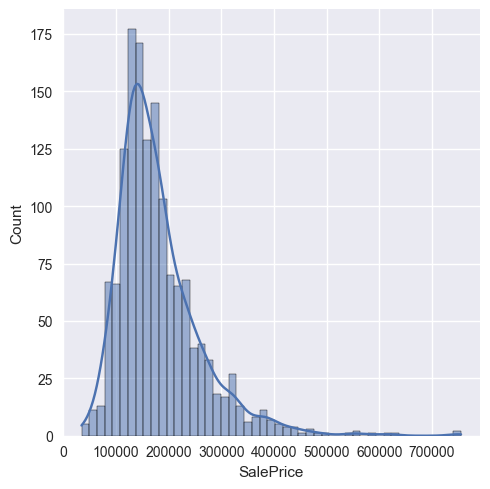

In [4]:
# distribution plot with normal fit
ax = sns.displot(data = train_raw['SalePrice'], kde=True)
plt.show()

The assocated p-value is : 3.2061412312021656e-33
With a threshold α = 0.05, we reject the null hypothesis


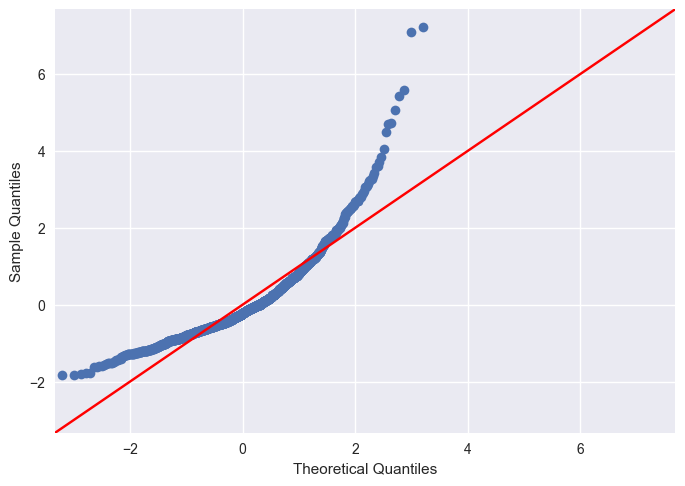

In [5]:
# Shapiro-Wilk Test for normality together with the Q-Q plot
alpha = 0.05
W, p = stats.shapiro(train_raw['SalePrice'])

print('The assocated p-value is : ' + str(p))

if p < alpha : 
    print('With a threshold α = ' + str(alpha) + ', we reject the null hypothesis')
else : 
    print('With a threshold α = ' + str(alpha) + ', we fail to reject the null hypothesis')
    
qqplot(train_raw['SalePrice'], dist = stats.distributions.norm, fit = True, line = '45')
plt.show()

La distribution n'est pas linéaire car il y a des valeurs extrême qui faussent les quantiles (certains biens vendus très chers en l'occurrence) . On va donc utilisé une formule logarithmique afin de pondéré et rendre l'impact des valeurs extrêmes plus proportionnelles.

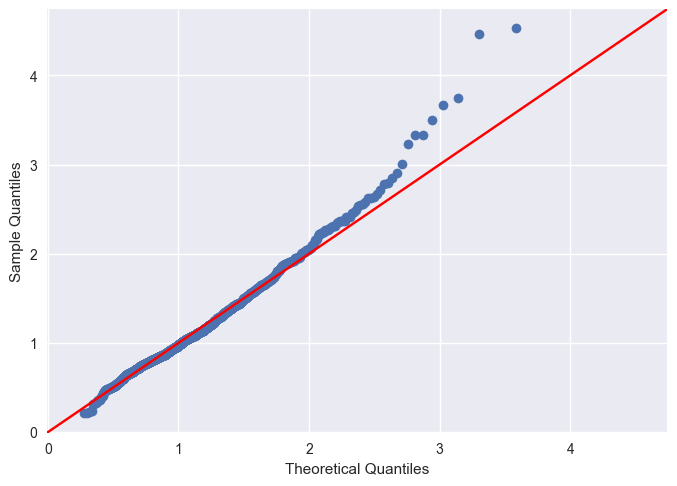

In [6]:
qqplot(train_raw['SalePrice'], dist = stats.distributions.lognorm, fit = True, line = '45')
plt.show()

Malgré la fonction logarithmique , certaines valeurs extrême émerge encore (maison chères) … ces données devront être analysées avec un éclairage métier afin de savoir si elles sont correctes. (par exemple une maison vendue en 99 en franc francais seraient super cher par rapport à une maison vendue en 2000 en euros)

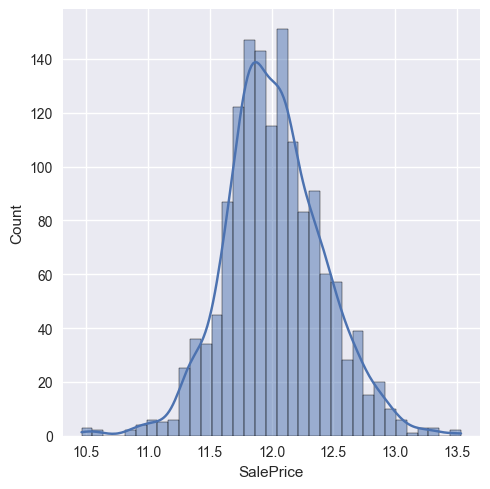

In [7]:
# new variable target which is the logarithm of the SalePrice
target = np.log1p(train_raw['SalePrice'])

# distribution plot
ax = sns.displot(data = target, kde=True)
plt.show()

## Traitement des données manquantes

On divise ensuite les variables en 3 catégories : ...

In [8]:
qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
              'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
              'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
              'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
              'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
              'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
              'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish', 
              'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
              'SaleType', 'SaleCondition', 'MoSold']

quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',  
               'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 
               'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 
               'PoolArea', 'MiscVal']

date = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']

In [9]:
data_raw = pd.concat([train_raw, validation_raw])

En ce qui concerne le traitement des données manquante , il faut être prudent et distinguer plusieurs cas, qui nécessiteront potentiellement des traitements différents.  Par exemple le nombre de mètres carrés d'une piscine: 0 veux dire qu'il n'y a pas de piscine ou alors qu'on ne sait pas sa taille? Dans ce cas on peut déduire que si il y a une piscine mais que son aire est à 0, on a pas l'info donc on peut y mettre la médiane par exemple.

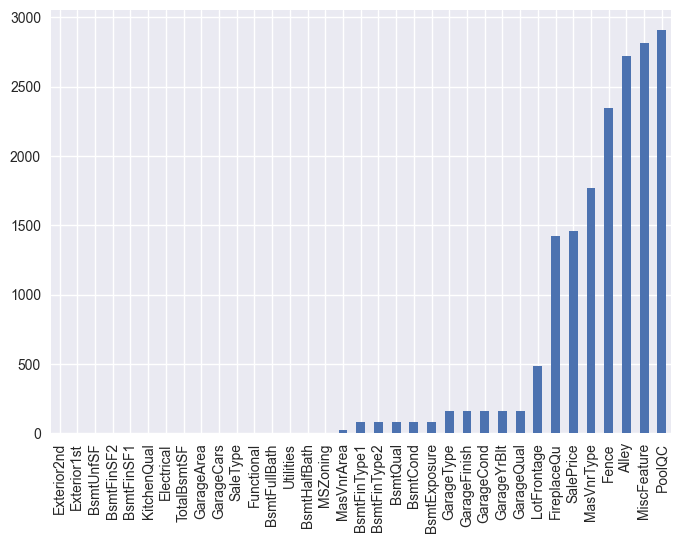

In [10]:
def plot_missing(data):

    missing = data.isnull().sum()
    missing = missing[missing > 0]
    
    if missing.empty:
        print('No missing values')
    else :
        missing.sort_values(inplace=True)
        missing.plot.bar()
    
        plt.show()

plot_missing(data_raw)

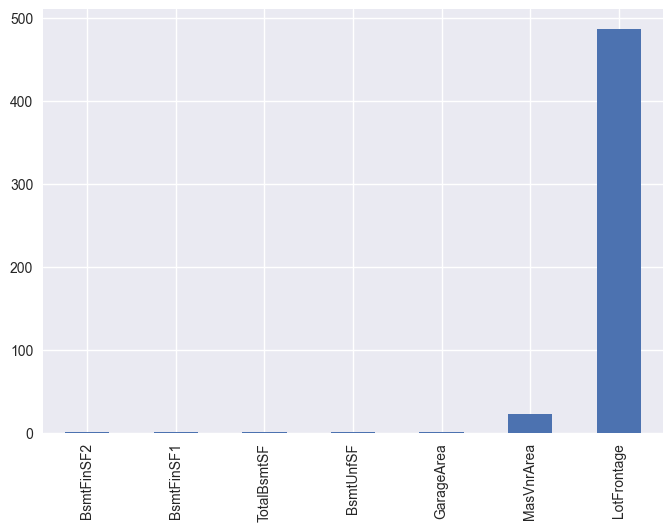

In [11]:
plot_missing(data_raw[quantitative])

In [12]:
# For quantitative variables, we will fill columns with 0
def fill_missing_with_constant(data, columns, constant):
    
    data_clean = data.copy()
    
    for c in columns :
        
        if data_clean[c].isnull().any():
            data_clean[c] = data_clean[c].fillna(constant)
    
    return data_clean

Voir les variables quantitatives manquantes :

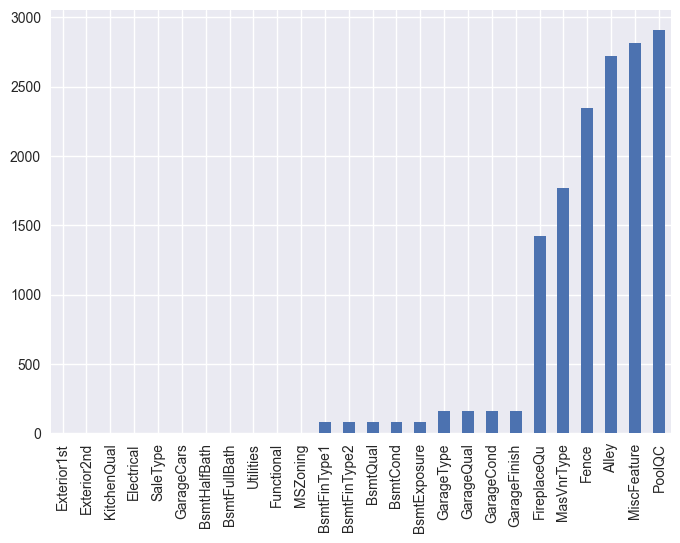

In [13]:
plot_missing(data_raw[qualitative])

Dates:
Données manquantes dans Garageyrbldt: on  met l'année de contruction de la maison (car en principe le garage est, au pire, aussi vieux que la maison mais pas plus)
 
afin de pouvoir exploiter des dates de façon mathématiques: il faut les transformer en nombre d'années.
1: année de vente - année de construction = nombre d'années qu'à la maison
2:  année de vente - année de rénovation =nombre d'années depuis la dernières rénovation
3: année de vente- année de construction garage = nombre d'années depuis la construction du garage

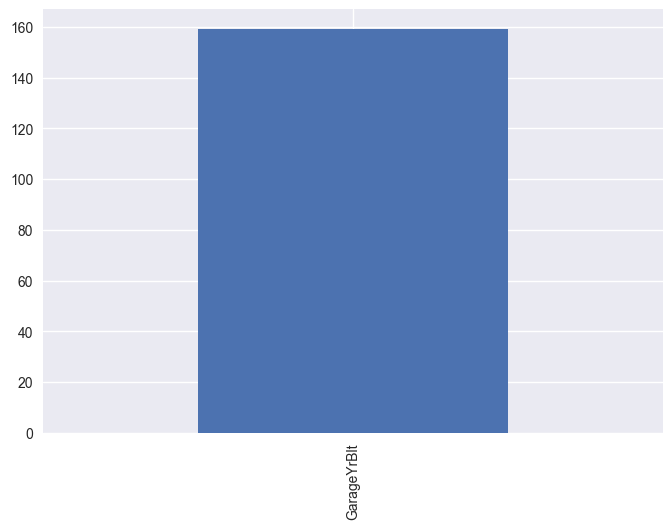

In [14]:
plot_missing(data_raw[date])

In [15]:
# For date variables, we will fill the missing values using the values from another column
def fill_missing_with_column(data, missing, column) :
    
    data_clean = data.copy()
    
    data_clean[missing] = np.where(data_clean[missing].isnull(), data_clean[column], data_clean[missing])
    
    return data_clean

## Transformation des dates

Transformer des dates absolues en durées relatives à la date de vente (YrSold) :

- Années depuis construction
- Années depuis rénovation
- Années depuis construction du garage

In [16]:
def compute_differences_to_year_sold(data) :
    
    data_clean = data.copy()
    
    data_clean['YearBuilt'] = data_clean['YrSold'] - data_clean['YearBuilt']
    data_clean['YearRemodAdd'] = data_clean['YrSold'] - data_clean['YearRemodAdd']
    data_clean['GarageYrBlt'] = data_clean['YrSold'] - data_clean['GarageYrBlt']
    
    return data_clean

## Nettoyage
On centralise toutes les étapes de nettoyage des données dans une seule fonction appelée clean(), afin de l’exécuter d’un seul coup sur le jeu de données brut (data_raw), qui contient à la fois le train et le test.

In [17]:
def clean(data) :
    
    data_clean = data.copy()
    
    # imputing missing variables
    data_clean = fill_missing_with_constant(data_clean, columns = quantitative, constant = 0)
    data_clean = fill_missing_with_constant(data_clean, columns = qualitative, constant = 'NA')
    data_clean = fill_missing_with_column(data_clean, missing = ['GarageYrBlt'], column = ['YearBuilt'])

    # transform date columns
    data_clean = compute_differences_to_year_sold(data_clean)
    
    return data_clean

On lance le process de nettoyage

In [18]:
data_clean = clean(data_raw)

data_clean.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500.0
2,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500.0
3,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500.0
4,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,Corner,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000.0
5,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000.0


# Modèle Baseline

**Section à supprimer ?**

Un modèle baseline est une première version simple d'un modèle de machine learning, utilisé comme point de comparaison pour évaluer les performances des modèles qui seront développés par la suite. Il permet d'établir un point de départ et ainsi identifier les apports des modèles plus complexes. Pour notre premier modèle, nous allons réaliser une régression linéaire simple.

JUSTIFIER

## Sélection des paramètres

Sélection basée sur la corrélation avec la méthode de Pearson. Pour ce faire, aucune transformation n’a été appliquée aux variables numériques, les variables catégorielles ont été encodées par la moyenne de la cible, et les variables de type date ont été transformées en nombre d’années depuis la vente.

Nous avons évité les variables trop liées entre elles grâce à la heatmap

[Introduire HeatMap]



Choix limité à 5 variables

Attention, d'un point de vue **interprétation**: les années ont une corrélation négative (plus c'est ancien, moins cela a de valeur)



**Variables**:
- OverallQual (l’évaluation globale de la qualité), Corrélation avec log(SalePrice) : +0.83 (la plus élevée)
- GrLivArea (surface habitable hors sous-sol, critère principal pour la taille du bien), Corrélation avec log(SalePrice) : +0.70
- TotalBsmtSF (surface totale du sous-sol, complète très bien GrLivArea en couvrant l’espace habitable invisible depuis les plans officiels,moins redondante que 1stFlrSF ou BsmtFinSF1), Corrélation avec log(SalePrice) : +0.62
- YearBuilt (l’ancienneté générale de la maison),capture toute l’infrastructure du bien. Des maisons anciennes dans des quartiers chers peuvent valoir plus qu’une maison récente dans un quartier médiocre. Corrélation négative avec log(SalePrice) : -0.59
- Neighborhood (quartier), variable la plus discriminante parmi toutes les catégorielles. Après son encodage en moyenne, corrélation de  +0.75 avec log(SalePrice)

**Utilité de chaque variable**:
- OverallQual: Qualité globale
- GrLivArea: Taille / Surface
- TotalBsmtSF: Surface complémentaire
- Neighborhood: Emplacement
- YearBuilt: Axe temporel

## Régression linéaire

Dans cette section, nous allons fit / adapter le modèle sur les données d'entraînement. Avant cela, nous devons séparer les données numériques, de celles catégoriques, afin d'apporter un traitement différent via des transformateurs. Ensuite un pipeline est créé pour regrouper les étapes à réaliser. Finalement, une cross-validation est réalisée afin de connaître le score moyen.

In [19]:
# Données nettoyées
data_clean = clean(data_raw)

# Variables de base
base = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'Neighborhood', 'YearBuilt']
x = data_clean[data_clean.index.isin(train_raw.index)][base].copy()
y = target.copy()

X_encoded = pd.get_dummies(x, columns=['Neighborhood'], drop_first=True)
X_array = sm.add_constant(X_encoded).astype(float)


import statsmodels.api as sm

# Création et entraînement du modèle de régression linéaire
model = sm.OLS(y, X_array)
results = model.fit()
print(results.summary())




                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     259.9
Date:                Thu, 29 May 2025   Prob (F-statistic):               0.00
Time:                        10:57:25   Log-Likelihood:                 586.90
No. Observations:                1460   AIC:                            -1116.
Df Residuals:                    1431   BIC:                            -962.5
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   10.9769 

### Assomptions du modèle

If we want to use a linear regression, we need to check certain assumptions, namely :

- Linearity of the link between the independant variables and the depedant variable
- Residuals are normally distributed around 0
- Homoscedasticity
- Residuals are free of structure
- Residuals are free of outliers

The following is a code I've found https://robert-alvarez.github.io/2018-06-04-diagnostic_plots/ which does this very well.

### VERFI ASSOMPTIONS

## Prédiction et soumission sur Kaggle

Une fois le modèle fit / adapté, nous pouvons prédire les valeurs cibles manquantes dans notre jeu de données de validation. Attention à ne pas le faire sur le jeu de données d'entraînement ! Cela ne sert à rien, le résultat sera biaisé car nous avons entraîné le modèle sur ces mêmes données.

Ensuite, nous allons exporter les prédictions dans un fichier csv, qui sera soumis à Kaggle. Ce modèle Baseline obtient un score de 0.16482.

-> A vérifier mais je dirais que pour chaque résultat il faut comparer en se basant sur RMSLE. Je l'ai fait sur RMSE mais peut-être faux, le RMSLE c'est pour les données logarithmiques ?$

Réponse GPT : "RMSLE est utile si tu prédis directement les prix bruts. Mais ici, tu prédis déjà le log → donc utilise RMSE directement."

# Pipeline

In [26]:
# ----------------------
# 1. Charger les données brutes
# ----------------------

from sklearn.pipeline import FunctionTransformer
from sklearn.preprocessing import StandardScaler



train_raw = pd.read_csv('Data/train.csv', index_col='Id')      # train.csv avec target SalePrice
test_raw = pd.read_csv('Data/test.csv', index_col='Id')        # test.csv sans SalePrice
data_raw = pd.concat([train_raw.drop(columns='SalePrice').copy(), test_raw.copy()])  # concat pour traitement centralisé

# ----------------------
# 2. Définir les colonnes utiles pour la pipeline
# ----------------------

numerical_cols = ['OverallQual', 'GrLivArea', 'TotalBsmtSF']  # numériques classiques
categorical_cols = ['Neighborhood']                                    # catégorielle importante
date_cols = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold']

# ----------------------
# 3. Fonction de transformation des dates en durées
# ----------------------

def compute_relative_dates(df):
    df = df.copy()
    df['YearsSinceBuilt'] = df['YrSold'] - df['YearBuilt']
    df['YearsSinceRemod'] = df['YrSold'] - df['YearRemodAdd']
    df['YearsSinceGarage'] = df['YrSold'] - df['GarageYrBlt'].fillna(df['YearBuilt'])
    return df[['YearsSinceBuilt', 'YearsSinceRemod', 'YearsSinceGarage']]


# Transformer scikit-learn compatible avec la nouvelle fonction date
date_transformer = Pipeline(steps=[
    ('relativedates', FunctionTransformer(compute_relative_dates, validate=False))
])

# ----------------------
# 4. Pipeline pour les colonnes numériques
# ----------------------

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),     # remplace les NaN par la moyenne
    ('scaler', StandardScaler())                     # normalise (utile pour modèles linéaires, SVM…)
])

# ----------------------
# 5. Pipeline pour les colonnes catégorielles
# ----------------------

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),  # ajoute une vraie catégorie "Missing"
    ('encoder', OneHotEncoder(handle_unknown='ignore'))                     # transforme en colonnes binaires, ignore les inconnues au test
])

# ----------------------
# 6. Assemblage global via ColumnTransformer
# ----------------------

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_cols),       # traitement des numériques
    ('cat', categorical_transformer, categorical_cols), # traitement des catégorielles
    ('dates', date_transformer, date_cols)              # traitement des dates
], remainder='drop')  

# ----------------------
# 7. Exemple d’utilisation (sans modèle)
# ----------------------

# Séparation train/test
X_train = data_raw.loc[train_raw.index]
X_test = data_raw.loc[test_raw.index]
y_train = target.copy()


# Step 3: Assemble the preprocessing pipeline
preprocessing_pipeline = Pipeline([
    ('preprocessor', preprocessor)
])


# Fit uniquement sur train
X_train_transformed = preprocessing_pipeline.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# X_train_transformed est maintenant prêt à être utilisé avec n’importe quel modèle
preprocessing_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['OverallQual', 'GrLivArea',
                                                   'TotalBsmtSF']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Neighborhood']),
                                                 ('dates',
                                                  Pipeline(steps=[('relativedates',
                                                                   FunctionTransformer(func=<function compute_relative_dates at 0x000001CAF27CD440>))]),
                                                  ['YearBuilt', 'YearRemodAdd',
                                                   'GarageYrBlt',
                                                   'YrSold'])]))])

# Modèle 1

Premier test avec un RandomForestRegressor

In [31]:
# 1. Cible log-transformée
y_train = target.copy()

# 2. Données d'entraînement issues du data_raw global
X_train = data_raw.loc[train_raw.index]

# 3. Hyperparamètres du modèle Random Forest
hyperparams = {
    'n_estimators': 100,
    'bootstrap': True,
    'max_features': 'sqrt',
    'random_state': 42,
    'n_jobs': -1
}

# 4. Pipeline complète : preprocessing + modèle
random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # pipeline définie précédemment
    ('regressor', RandomForestRegressor(**hyperparams))
])

random_forest_pipeline.fit(X_train, y)


# 5. Évaluation avec cross-validation (sans fit préalable)
scores = cross_val_score(
    random_forest_pipeline,     # pipeline complète
    X_train,                    # features brutes (non transformées)
    y_train,                    # cible log-transformée
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# 6. Transformation en RMSE
rmse_scores = np.sqrt(-scores)
print("RMSE moyen :", rmse_scores.mean())

random_forest_pipeline


RMSE moyen : 0.1508021663355012


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['OverallQual', 'GrLivArea',
                                                   'TotalBsmtSF']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Neighborhood']),
                                                 ('dates',
                                                  Pipeline(steps=[('relativedates',
                                                                   FunctionTransformer(func=<function compute_relative_dates at 0x000001CAF27CD440>))]),
                                                  ['YearBuilt', 'YearRemodAdd',
                                                   'GarageYrBlt',
                                                   'YrSold'])])),
                ('regressor',
                 RandomForestRegressor(max_features='sqrt', n_jobs=-1,
                                       random_state=42))])

Ce modèle n'est pas optimisé, c'est juste un test ! Il obtient un score de X sur Kaggle.

## Le modèle

## Les paramètres

Itération 1

Itération 2

## Overfitting

Dire qu'il peut y avoir un 2e sweet spot

## Hyparamètres

Itération 1

Itération 2

## Entraînement

## Le résultat

Itération 1

Itération 2

# Modèle 2

## Le modèle

## Les paramètres

Itération 1

Itération 2

## Hyparamètres

Itération 1

Itération 2

## Entraînement

## Le résultat

Itération 1

Itération 2

# Conclusion

Ophélie

## Éthique